In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from datasets import load_dataset
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("Num GPUs:", len(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
Num GPUs: 2


In [2]:

dataset = load_dataset("mattmdjaga/human_parsing_dataset")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002-f3a663f7140ee7(…):   0%|          | 0.00/394M [00:00<?, ?B/s]

data/train-00001-of-00002-74610e243c32d5(…):   0%|          | 0.00/403M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/17706 [00:00<?, ? examples/s]

In [9]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'mask'],
        num_rows: 17706
    })
})

In [4]:
import numpy as np

all_ids = set()

for i in range(len(dataset["train"])):
    mask = np.array(dataset["train"][i]["mask"])
    all_ids.update(np.unique(mask).tolist())

all_ids = sorted(all_ids)

print("Class IDs:")
print(all_ids)

print("\nNumber of observed IDs:", len(all_ids))
print("Minimum ID:", min(all_ids))
print("Maximum ID:", max(all_ids))

Class IDs:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

Number of observed IDs: 18
Minimum ID: 0
Maximum ID: 17


In [3]:
print(dataset["train"].features["mask"])
print(dataset["train"].features)

Image(mode=None, decode=True)
{'image': Image(mode=None, decode=True), 'mask': Image(mode=None, decode=True)}


In [4]:
train_ds = dataset["train"]

print("Number of samples:", len(train_ds))
print("Features:", train_ds.features)
print("First sample keys:", train_ds[0].keys())

Number of samples: 17706
Features: {'image': Image(mode=None, decode=True), 'mask': Image(mode=None, decode=True)}
First sample keys: dict_keys(['image', 'mask'])


In [5]:
# ============================================================
# Configuration
# ============================================================

SEED = 42

IMAGE_HEIGHT = 512
IMAGE_WIDTH = 512
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)

NUM_CLASSES = 18

BATCH_SIZE = 8
EPOCHS = 6

LEARNING_RATE = 1e-3

VAL_RATIO = 0.10
TEST_RATIO = 0.10

AUTOTUNE = tf.data.AUTOTUNE

print("NUM_CLASSES:", NUM_CLASSES)
print("IMAGE_SIZE:", IMAGE_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("EPOCHS:", EPOCHS)

NUM_CLASSES: 18
IMAGE_SIZE: (512, 512)
BATCH_SIZE: 8
EPOCHS: 6


In [6]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
sample = train_ds[0]

image = np.array(sample["image"])
mask = np.array(sample["mask"])

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)

print("Mask shape:", mask.shape)
print("Mask dtype:", mask.dtype)

print("Mask unique values:", np.unique(mask))

Image shape: (600, 400, 3)
Image dtype: uint8
Mask shape: (600, 400)
Mask dtype: uint8
Mask unique values: [ 0  2  7  8  9 10 11 12 13 14 15 16]


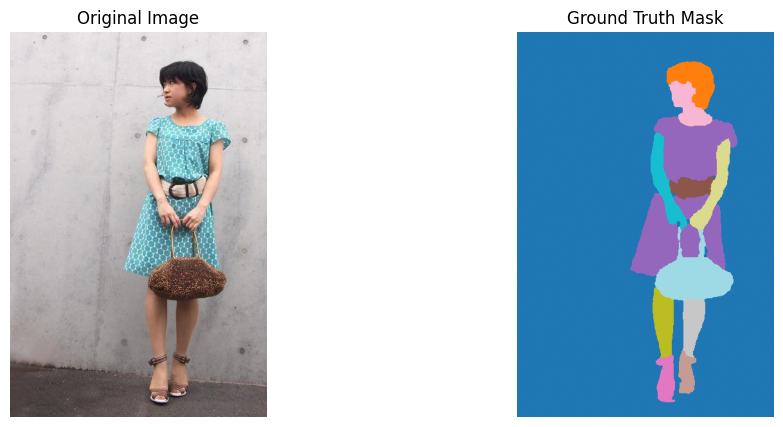

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="tab20")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

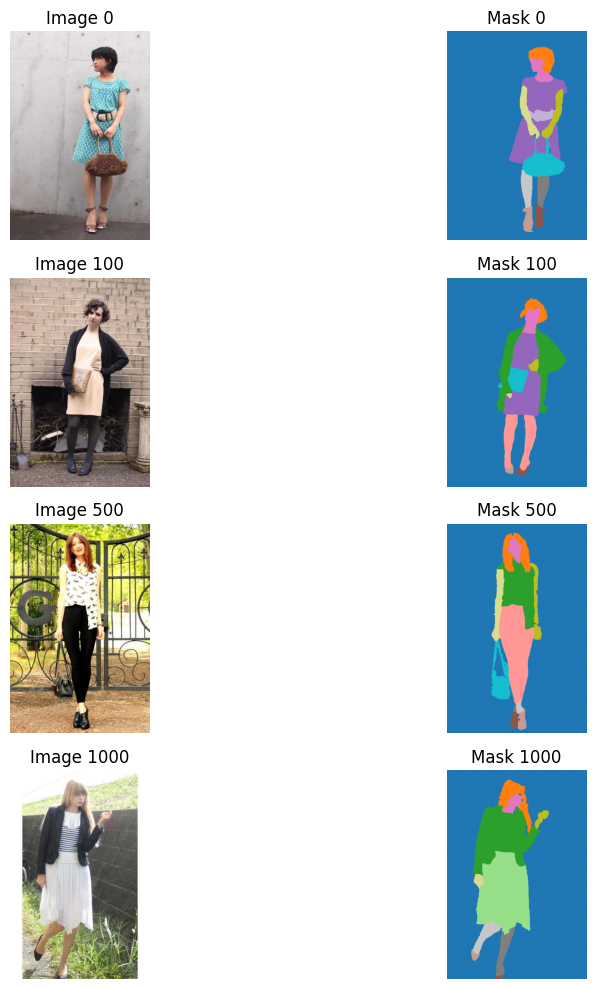

In [11]:
indices = [0, 100, 500, 1000]

plt.figure(figsize=(12, 10))

for row, idx in enumerate(indices):
    
    image = np.array(train_ds[idx]["image"])
    mask = np.array(train_ds[idx]["mask"])
    
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    plt.subplot(len(indices), 2, row * 2 + 1)
    plt.imshow(image)
    plt.title(f"Image {idx}")
    plt.axis("off")

    plt.subplot(len(indices), 2, row * 2 + 2)
    plt.imshow(mask, cmap="tab20", vmin=0, vmax=17)
    plt.title(f"Mask {idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# First split: 80% train, 20% temporary
split_1 = train_ds.train_test_split(
    test_size=0.20,
    seed=SEED
)

train_data = split_1["train"]
temp_data = split_1["test"]

# Second split: half validation, half test
split_2 = temp_data.train_test_split(
    test_size=0.50,
    seed=SEED
)

val_data = split_2["train"]
test_data = split_2["test"]

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 14164
Validation: 1771
Test: 1771


In [9]:
def preprocess_sample(image, mask):
    
    # -----------------------------
    # Image
    # -----------------------------
    image = np.array(image.convert("RGB"))
    
    # Normalize image
    image = image.astype(np.float32) / 255.0
    
    # -----------------------------
    # Mask
    # -----------------------------
    mask = np.array(mask)
    
    # Mask should be H x W
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    
    mask = mask.astype(np.int32)
    
    # -----------------------------
    # Resize
    # -----------------------------
    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method="bilinear"
    )
    
    mask = tf.image.resize(
        mask[..., None],
        IMAGE_SIZE,
        method="nearest"
    )
    
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.cast(mask, tf.int32)
    
    return image, mask

In [10]:
image, mask = preprocess_sample(
    train_data[0]["image"],
    train_data[0]["mask"]
)

print("Processed image shape:", image.shape)
print("Processed mask shape:", mask.shape)

print("Image min:", tf.reduce_min(image).numpy())
print("Image max:", tf.reduce_max(image).numpy())

print("Mask unique IDs:", np.unique(mask.numpy()))

Processed image shape: (512, 512, 3)
Processed mask shape: (512, 512)
Image min: 0.0
Image max: 1.0
Mask unique IDs: [ 0  2  4  7 10 11 12 13 14 15 16]


I0000 00:00:1788879480.929860      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788879480.932548      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [11]:
def augment(image, mask):
    
    # Horizontal flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask[..., None])
        mask = tf.squeeze(mask, axis=-1)
    
    # Brightness
    image = tf.image.random_brightness(
        image,
        max_delta=0.10
    )
    
    # Contrast
    image = tf.image.random_contrast(
        image,
        lower=0.9,
        upper=1.1
    )
    
    image = tf.clip_by_value(image, 0.0, 1.0)
    
    return image, mask

In [12]:
def data_generator(hf_dataset, training=False):
    
    for i in range(len(hf_dataset)):
        
        image = hf_dataset[i]["image"]
        mask = hf_dataset[i]["mask"]
        
        image, mask = preprocess_sample(image, mask)
        
        if training:
            image, mask = augment(image, mask)
        
        yield image, mask

In [13]:
output_signature = (
    tf.TensorSpec(
        shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3),
        dtype=tf.float32
    ),
    tf.TensorSpec(
        shape=(IMAGE_HEIGHT, IMAGE_WIDTH),
        dtype=tf.int32
    )
)

In [14]:
train_tf = tf.data.Dataset.from_generator(
    lambda: data_generator(train_data, training=True),
    output_signature=output_signature
)

train_tf = (
    train_tf
    .shuffle(512, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [15]:
val_tf = tf.data.Dataset.from_generator(
    lambda: data_generator(val_data, training=False),
    output_signature=output_signature
)

val_tf = (
    val_tf
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [16]:
test_tf = tf.data.Dataset.from_generator(
    lambda: data_generator(test_data, training=False),
    output_signature=output_signature
)

test_tf = (
    test_tf
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [17]:
images, masks = next(iter(train_tf))

print("Images:", images.shape)
print("Masks:", masks.shape)

print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)

print("Mask min:", tf.reduce_min(masks).numpy())
print("Mask max:", tf.reduce_max(masks).numpy())

Images: (8, 512, 512, 3)
Masks: (8, 512, 512)
Image dtype: <dtype: 'float32'>
Mask dtype: <dtype: 'int32'>
Mask min: 0
Mask max: 16


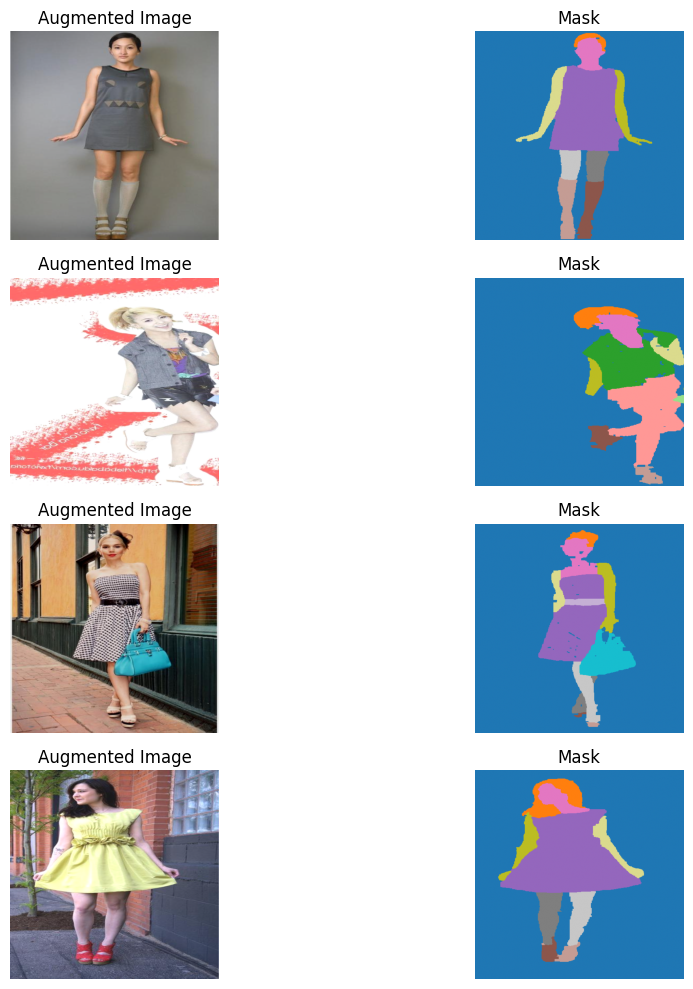

In [22]:
plt.figure(figsize=(12, 10))

for i in range(4):
    
    plt.subplot(4, 2, i * 2 + 1)
    plt.imshow(images[i])
    plt.title("Augmented Image")
    plt.axis("off")
    
    plt.subplot(4, 2, i * 2 + 2)
    plt.imshow(masks[i], cmap="tab20", vmin=0, vmax=17)
    plt.title("Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
from tensorflow.keras import layers, Model

In [24]:
def aspp_block(x, filters=256):
    input_shape = x.shape
    h, w = input_shape[1], input_shape[2]

    # 1x1 convolution
    b0 = layers.Conv2D(
        filters, 1, padding="same", use_bias=False
    )(x)
    b0 = layers.BatchNormalization()(b0)
    b0 = layers.ReLU()(b0)

    # Dilated convolution - rate 6
    b1 = layers.Conv2D(
        filters, 3, padding="same",
        dilation_rate=6, use_bias=False
    )(x)
    b1 = layers.BatchNormalization()(b1)
    b1 = layers.ReLU()(b1)

    # Dilated convolution - rate 12
    b2 = layers.Conv2D(
        filters, 3, padding="same",
        dilation_rate=12, use_bias=False
    )(x)
    b2 = layers.BatchNormalization()(b2)
    b2 = layers.ReLU()(b2)

    # Dilated convolution - rate 18
    b3 = layers.Conv2D(
        filters, 3, padding="same",
        dilation_rate=18, use_bias=False
    )(x)
    b3 = layers.BatchNormalization()(b3)
    b3 = layers.ReLU()(b3)

    # Global average pooling branch
    b4 = layers.GlobalAveragePooling2D()(x)
    b4 = layers.Reshape((1, 1, input_shape[-1]))(b4)
    b4 = layers.Conv2D(
        filters, 1, padding="same", use_bias=False
    )(b4)
    b4 = layers.BatchNormalization()(b4)
    b4 = layers.ReLU()(b4)

    b4 = layers.Resizing(h, w, interpolation="bilinear")(b4)

    # Concatenate ASPP branches
    x = layers.Concatenate()([b0, b1, b2, b3, b4])

    x = layers.Conv2D(
        filters, 1, padding="same", use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Dropout(0.1)(x)

    return x


In [25]:
def build_deeplabv3_resnet50(
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3),
    num_classes=NUM_CLASSES
):

    # IMPORTANT:
    # Create the input first
    inputs = layers.Input(shape=input_shape)

    # Create ResNet50 backbone
    backbone = ResNet50(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    # High-level features for ASPP (stride 16)
    high_level = backbone.get_layer(
        "conv4_block6_out"
    ).output

    # Low-level features for the skip connection (stride 4) --
    # this is the key addition that turns DeepLabV3 into DeepLabV3+
    low_level = backbone.get_layer(
        "conv2_block3_out"
    ).output

    # ASPP on high-level features
    x = aspp_block(high_level, filters=256)

    # Upsample ASPP output up to the low-level feature map's resolution
    low_h, low_w = low_level.shape[1], low_level.shape[2]
    x = layers.Resizing(low_h, low_w, interpolation="bilinear")(x)

    # Project low-level features to fewer channels before concatenating
    # (48 channels, as in the original DeepLabV3+ paper -- keeps the skip
    # connection from dominating the richer ASPP features)
    low_level_proj = layers.Conv2D(
        48, 1, padding="same", use_bias=False
    )(low_level)
    low_level_proj = layers.BatchNormalization()(low_level_proj)
    low_level_proj = layers.ReLU()(low_level_proj)

    # Fuse high-level context with low-level spatial detail
    x = layers.Concatenate()([x, low_level_proj])

    # Refine the fused features
    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Upsample back to original image size
    x = layers.Resizing(
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        interpolation="bilinear"
    )(x)

    # 18 classes
    outputs = layers.Conv2D(
        num_classes,
        1,
        padding="same",
        activation="softmax"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="DeepLabV3Plus_ResNet50"
    )

    return model

In [26]:
model = build_deeplabv3_resnet50()

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "DeepLabV3Plus_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 518, 518,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 256, 256,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 256, 256,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 256, 256,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 258, 258,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 128, 128,  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 128, 128,  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 128, 128,  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 128, 128,  │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 128, 128,  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 128, 128,  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 128, 128,  │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 128, 128,  │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 128, 128,  │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 128, 128,  │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 128, 128,  │      1,024 │ conv2_block1_3_c

 Total params: 17,834,578 (68.03 MB)

 Trainable params: 17,799,794 (67.90 MB)

 Non-trainable params: 34,784 (135.88 KB)

In [27]:
dummy = tf.random.normal(
    (2, IMAGE_HEIGHT, IMAGE_WIDTH, 3)
)

pred = model(dummy)

print("Prediction shape:", pred.shape)

Prediction shape: (2, 512, 512, 18)


In [19]:
# ============================================================
# Class weights (to handle class imbalance in mIoU)
# ============================================================
# We estimate how many pixels belong to each of the 18 classes using a
# random sample of the training set (fast + representative), then give
# rare classes a bigger weight in the loss so the model is pushed to
# learn them instead of only optimizing the dominant classes.

def compute_class_weights(hf_dataset, num_classes, max_samples=1000, seed=SEED):
    counts = np.zeros(num_classes, dtype=np.float64)

    n = min(max_samples, len(hf_dataset))
    rng = np.random.RandomState(seed)
    idxs = rng.choice(len(hf_dataset), size=n, replace=False)

    for i in idxs:
        mask = np.array(hf_dataset[int(i)]["mask"])

        if mask.ndim == 3:
            mask = mask[:, :, 0]

        vals, cnts = np.unique(mask, return_counts=True)

        for v, c in zip(vals, cnts):
            if 0 <= v < num_classes:
                counts[v] += c

    # Avoid division by zero for classes that never appeared in the sample
    counts = np.clip(counts, 1, None)

    freq = counts / counts.sum()

    # Inverse sqrt frequency: smoother than plain 1/freq, avoids exploding
    # weights for extremely rare classes while still boosting them.
    weights = 1.0 / np.sqrt(freq)

    # Normalize so the average weight is ~1 (keeps loss scale stable)
    weights = weights / weights.mean()

    return weights.astype(np.float32)


class_weights = compute_class_weights(
    train_data,
    NUM_CLASSES,
    max_samples=1000
)

print("Per-class weights:")
for class_id, w in enumerate(class_weights):
    print(f"  Class {class_id}: {w:.3f}")

class_weights_tf = tf.constant(class_weights, dtype=tf.float32)


Per-class weights:
  Class 0: 0.081
  Class 1: 1.498
  Class 2: 0.481
  Class 3: 2.916
  Class 4: 0.284
  Class 5: 0.520
  Class 6: 0.432
  Class 7: 0.464
  Class 8: 2.970
  Class 9: 1.014
  Class 10: 1.035
  Class 11: 0.663
  Class 12: 0.748
  Class 13: 0.755
  Class 14: 0.839
  Class 15: 0.863
  Class 16: 0.714
  Class 17: 1.724


In [20]:
def multiclass_dice_loss(
    y_true,
    y_pred,
    smooth=1e-6,
    class_weights=None
):

    # y_true:
    # (B, H, W)

    # y_pred:
    # (B, H, W, C)

    y_true = tf.cast(y_true, tf.int32)

    y_true_one_hot = tf.one_hot(
        y_true,
        depth=NUM_CLASSES
    )

    y_true_one_hot = tf.cast(
        y_true_one_hot,
        tf.float32
    )

    # Flatten spatial dimensions
    y_true_flat = tf.reshape(
        y_true_one_hot,
        [tf.shape(y_true_one_hot)[0], -1, NUM_CLASSES]
    )

    y_pred_flat = tf.reshape(
        y_pred,
        [tf.shape(y_pred)[0], -1, NUM_CLASSES]
    )

    intersection = tf.reduce_sum(
        y_true_flat * y_pred_flat,
        axis=1
    )

    denominator = (
        tf.reduce_sum(y_true_flat, axis=1)
        +
        tf.reduce_sum(y_pred_flat, axis=1)
    )

    dice_per_class = (
        2.0 * intersection + smooth
    ) / (
        denominator + smooth
    )

    if class_weights is not None:
        # Weighted average across classes instead of a plain mean, so
        # rare classes contribute more to the loss.
        weighted_dice = tf.reduce_sum(
            dice_per_class * class_weights, axis=-1
        ) / tf.reduce_sum(class_weights)
    else:
        weighted_dice = tf.reduce_mean(dice_per_class, axis=-1)

    return 1.0 - tf.reduce_mean(weighted_dice)


In [21]:
def weighted_focal_loss(
    y_true,
    y_pred,
    gamma=2.0,
    class_weights=None
):
    # Focal loss down-weights easy, already-correct pixels and focuses
    # training on hard / misclassified ones, which is exactly the
    # problem with plain cross-entropy on an imbalanced 18-class mask
    # (a few dominant classes dominate the gradient otherwise).

    y_true = tf.cast(y_true, tf.int32)

    y_true_one_hot = tf.one_hot(
        y_true,
        depth=NUM_CLASSES
    )
    y_true_one_hot = tf.cast(y_true_one_hot, tf.float32)

    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

    cross_entropy = -y_true_one_hot * tf.math.log(y_pred)

    modulating_factor = tf.pow(1.0 - y_pred, gamma)

    focal = modulating_factor * cross_entropy

    if class_weights is not None:
        focal = focal * class_weights

    # Sum over classes, mean over batch + pixels
    focal = tf.reduce_sum(focal, axis=-1)

    return tf.reduce_mean(focal)


In [22]:
def combined_loss(y_true, y_pred):

    focal = weighted_focal_loss(
        y_true,
        y_pred,
        gamma=2.0,
        class_weights=class_weights_tf
    )

    dice = multiclass_dice_loss(
        y_true,
        y_pred,
        class_weights=class_weights_tf
    )

    # Dice correlates directly with IoU, so we weight it a bit more
    # heavily than before (was 0.4) to push mIoU up specifically.
    return 0.5 * focal + 0.5 * dice


In [23]:
def mean_iou_metric(y_true, y_pred):
    
    # y_true:
    # (B, H, W)
    
    # y_pred:
    # (B, H, W, 18)
    
    # Convert probabilities → class IDs
    y_pred = tf.argmax(
        y_pred,
        axis=-1
    )
    
    y_pred = tf.cast(
        y_pred,
        tf.int32
    )
    
    y_true = tf.cast(
        y_true,
        tf.int32
    )
    
    # Flatten
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    
    # Confusion matrix
    confusion_matrix = tf.math.confusion_matrix(
        y_true,
        y_pred,
        num_classes=NUM_CLASSES,
        dtype=tf.float32
    )
    
    # Intersection
    intersection = tf.linalg.diag_part(
        confusion_matrix
    )
    
    # Union
    ground_truth_pixels = tf.reduce_sum(
        confusion_matrix,
        axis=1
    )
    
    predicted_pixels = tf.reduce_sum(
        confusion_matrix,
        axis=0
    )
    
    union = (
        ground_truth_pixels
        + predicted_pixels
        - intersection
    )
    
    iou = (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )
    
    # Ignore classes that don't exist in GT
    valid = union > 0
    
    iou = tf.boolean_mask(
        iou,
        valid
    )
    
    return tf.reduce_mean(iou)

In [33]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)

model.compile(
    optimizer=optimizer,
    loss=combined_loss,
    metrics=[
        "sparse_categorical_accuracy",
        mean_iou_metric
    ]
)

In [34]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_unet.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

In [35]:
history = model.fit(
    train_tf,
    validation_data=val_tf,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/6


2026-09-08 07:27:28.256612: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{} for conv (f32[1152,256,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[1152,1024,5,5]{3,2,1,0}, f32[256,1024,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-09-08 07:27:28.260907: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.004396485s
Trying algorithm eng4{} for conv (f32[1152,256,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[1152,1024,5,5]{3,2,1,0}, f32[256,1024,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_q

   1770/Unknown 2513s 1s/step - loss: 0.4620 - mean_iou_metric: 0.3269 - sparse_categorical_accuracy: 0.8551

2026-09-08 08:08:57.797986: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{} for conv (f32[1024,1296,4,4]{3,2,1,0}, u8[0]{0}) custom-call(f32[1024,256,3,3]{3,2,1,0}, f32[1296,256,2,2]{3,2,1,0}), window={size=2x2 pad=1_1x1_1 rhs_reversal=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-09-08 08:08:58.201314: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.403449282s
Trying algorithm eng4{} for conv (f32[1024,1296,4,4]{3,2,1,0}, u8[0]{0}) custom-call(f32[1024,256,3,3]{3,2,1,0}, f32[1296,256,2,2]{3,2,1,0}), window={size=2x2 pad=1_1x1_1 rhs_reversal=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", bac

   1771/Unknown 2583s 1s/step - loss: 0.4620 - mean_iou_metric: 0.3269 - sparse_categorical_accuracy: 0.8551
Epoch 1: val_loss improved from None to 0.43755, saving model to best_unet.keras

Epoch 1: finished saving model to best_unet.keras
1771/1771 ━━━━━━━━━━━━━━━━━━━━ 2725s 1s/step - loss: 0.4375 - mean_iou_metric: 0.3672 - sparse_categorical_accuracy: 0.8828 - val_loss: 0.4375 - val_mean_iou_metric: 0.3855 - val_sparse_categorical_accuracy: 0.8912 - learning_rate: 0.0010
Epoch 2/6
1771/1771 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.4163 - mean_iou_metric: 0.4164 - sparse_categorical_accuracy: 0.9049
Epoch 2: val_loss did not improve from 0.43755
1771/1771 ━━━━━━━━━━━━━━━━━━━━ 2536s 1s/step - loss: 0.4126 - mean_iou_metric: 0.4262 - sparse_categorical_accuracy: 0.9082 - val_loss: 0.5065 - val_mean_iou_metric: 0.2530 - val_sparse_categorical_accuracy: 0.5757 - learning_rate: 0.0010
Epoch 3/6
1771/1771 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.4061 - mean_iou_metric: 0.4469 - sparse_c

In [36]:
model.save("human_parsing_unet_18_classes.keras")
print("Model saved successfully.")

Model saved successfully.


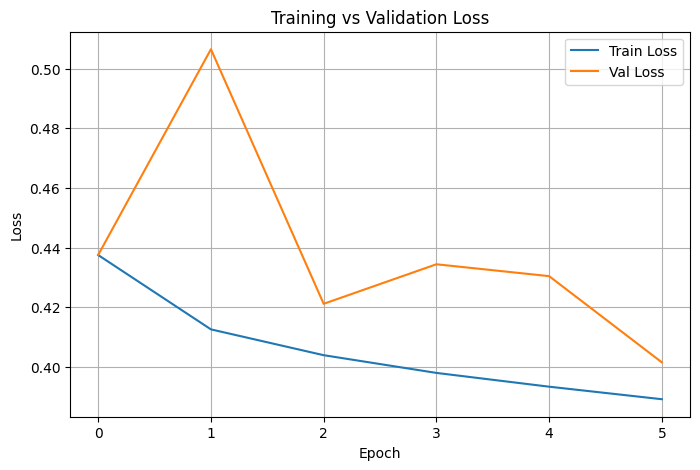

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

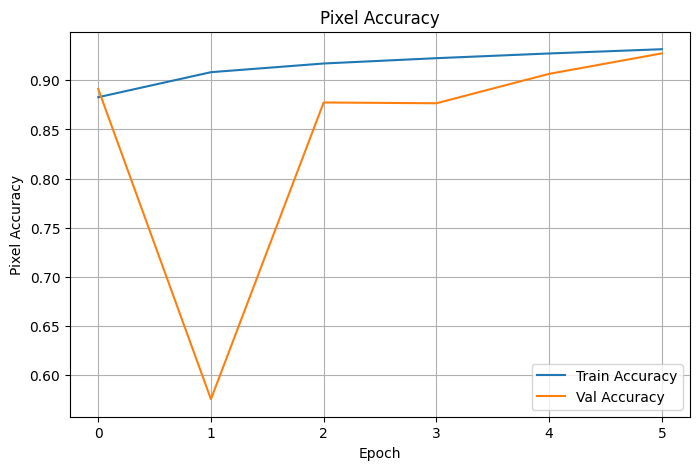

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["sparse_categorical_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_sparse_categorical_accuracy"],
    label="Val Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Pixel Accuracy")
plt.title("Pixel Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
test_results = model.evaluate(
    test_tf,
    return_dict=True
)

print(test_results)

222/222 ━━━━━━━━━━━━━━━━━━━━ 127s 570ms/step - loss: 0.3964 - mean_iou_metric: 0.5133 - sparse_categorical_accuracy: 0.9309
{'loss': 0.39636334776878357, 'mean_iou_metric': 0.5132785439491272, 'sparse_categorical_accuracy': 0.9308958053588867}


In [24]:
# Reload the trained model safely (works even if the kernel restarted
# and lost the in-memory `model`/`class_weights_tf` variables).

if "class_weights_tf" not in dir():
    class_weights_tf = tf.ones(NUM_CLASSES, dtype=tf.float32)
    print("Warning: class_weights_tf not found in memory, using dummy weights "
          "(fine for loading/evaluation, since weights only affect training).")

model = tf.keras.models.load_model(
    "human_parsing_unet_18_classes.keras",
    custom_objects={
        "combined_loss": combined_loss,
        "mean_iou_metric": mean_iou_metric,
    }
)

print("Model loaded successfully.")

Model loaded successfully.


In [34]:
def calculate_per_class_iou(
    y_true,
    y_pred,
    num_classes
):
    
    ious = []
    
    for class_id in range(num_classes):
        
        true_class = (y_true == class_id)
        pred_class = (y_pred == class_id)
        
        intersection = np.logical_and(
            true_class,
            pred_class
        ).sum()
        
        union = np.logical_or(
            true_class,
            pred_class
        ).sum()
        
        if union == 0:
            iou = np.nan
        else:
            iou = intersection / union
        
        ious.append(iou)
    
    return np.array(ious)

In [35]:
all_true = []
all_pred = []

for images_batch, masks_batch in test_tf:
    
    probs = model.predict(
        images_batch,
        verbose=0
    )
    
    preds = np.argmax(
        probs,
        axis=-1
    )
    
    all_true.append(
        masks_batch.numpy()
    )
    
    all_pred.append(
        preds
    )

all_true = np.concatenate(all_true, axis=0)
all_pred = np.concatenate(all_pred, axis=0)

print("True masks:", all_true.shape)
print("Pred masks:", all_pred.shape)

2026-09-08 12:50:46.731344: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{} for conv (f32[1152,256,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[1152,1024,5,5]{3,2,1,0}, f32[256,1024,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-09-08 12:50:46.953577: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.222394551s
Trying algorithm eng4{} for conv (f32[1152,256,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[1152,1024,5,5]{3,2,1,0}, f32[256,1024,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_q

True masks: (1771, 512, 512)
Pred masks: (1771, 512, 512)


In [36]:
class_ious = calculate_per_class_iou(
    all_true,
    all_pred,
    NUM_CLASSES
)

for class_id, iou in enumerate(class_ious):
    
    if np.isnan(iou):
        print(f"Class {class_id}: N/A")
    else:
        print(
            f"Class {class_id}: "
            f"IoU = {iou:.4f}"
        )

mean_iou_score = np.nanmean(class_ious)

print("\nMean IoU:", mean_iou_score)

Class 0: IoU = 0.9743
Class 1: IoU = 0.6718
Class 2: IoU = 0.7738
Class 3: IoU = 0.6238
Class 4: IoU = 0.7180
Class 5: IoU = 0.5172
Class 6: IoU = 0.7351
Class 7: IoU = 0.4558
Class 8: IoU = 0.3458
Class 9: IoU = 0.2886
Class 10: IoU = 0.2860
Class 11: IoU = 0.8195
Class 12: IoU = 0.3975
Class 13: IoU = 0.3702
Class 14: IoU = 0.2611
Class 15: IoU = 0.3817
Class 16: IoU = 0.6338
Class 17: IoU = 0.3514

Mean IoU: 0.533635991909025


In [37]:
def predict_image(model, image_path):
    
    image = Image.open(image_path).convert("RGB")
    
    original = np.array(image)
    
    image_resized = tf.image.resize(
        original,
        IMAGE_SIZE,
        method="bilinear"
    )
    
    image_resized = (
        tf.cast(image_resized, tf.float32) / 255.0
    )
    
    image_batch = tf.expand_dims(
        image_resized,
        axis=0
    )
    
    prediction = model.predict(
        image_batch,
        verbose=0
    )[0]
    
    pred_mask = np.argmax(
        prediction,
        axis=-1
    )
    
    return original, pred_mask

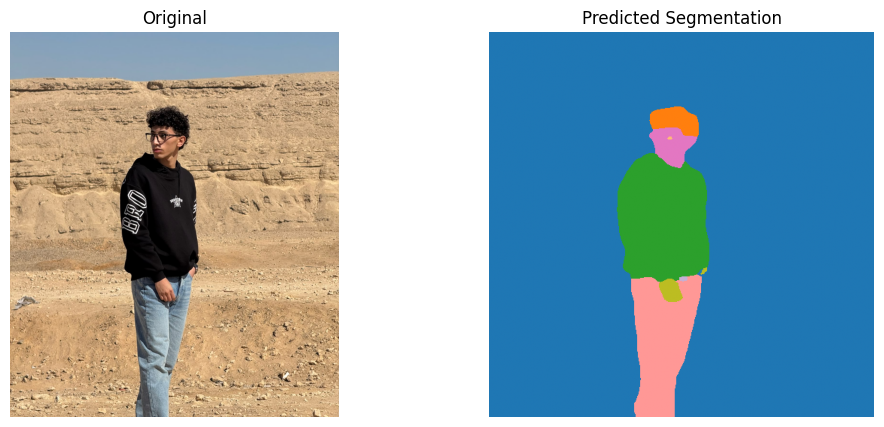

In [40]:
image_path = "/kaggle/input/datasets/mahmoudadelv12/test111/WhatsApp Image 2026-09-08 at 4.08.07 PM.jpeg"

original, prediction = predict_image(
    model,
    image_path
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    prediction,
    cmap="tab20",
    vmin=0,
    vmax=17
)
plt.title("Predicted Segmentation")
plt.axis("off")

plt.show()

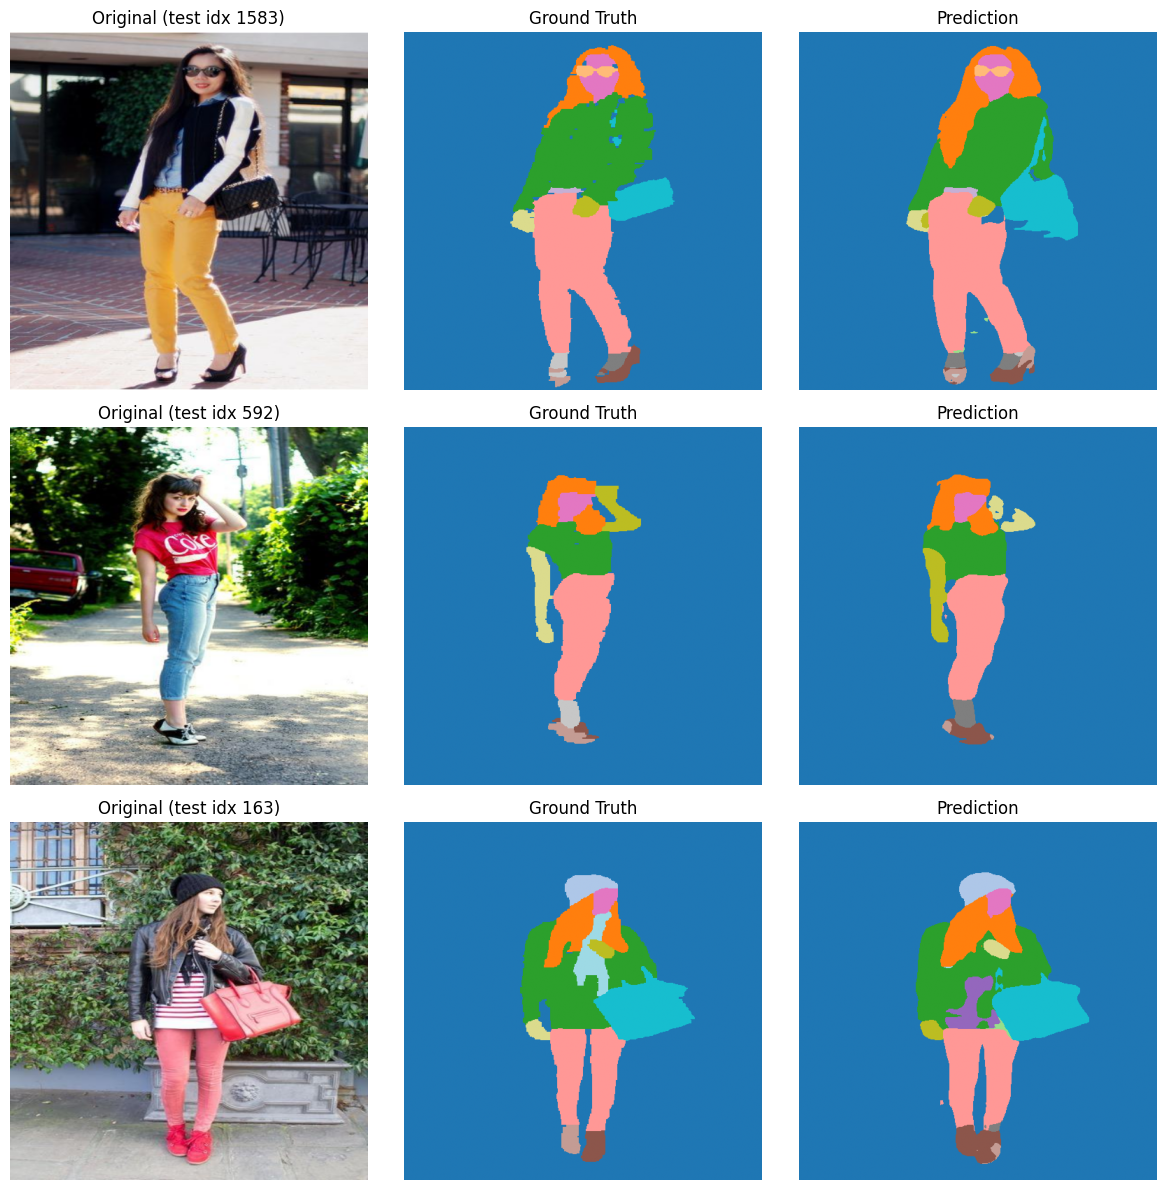

In [34]:
# ============================================================
# Qualitative results: Original vs Ground Truth vs Prediction
# (sampled from the TEST set, so we have real ground truth)
# ============================================================

import random

NUM_QUALITATIVE_SAMPLES = 3
sample_indices = random.sample(range(len(test_data)), NUM_QUALITATIVE_SAMPLES)

plt.figure(figsize=(12, 4 * NUM_QUALITATIVE_SAMPLES))

for row, idx in enumerate(sample_indices):

    # Preprocess exactly like training/eval
    image, mask = preprocess_sample(
        test_data[idx]["image"],
        test_data[idx]["mask"]
    )

    image_batch = tf.expand_dims(image, axis=0)

    pred = model.predict(image_batch, verbose=0)[0]
    pred_mask = np.argmax(pred, axis=-1)

    # Original image
    plt.subplot(NUM_QUALITATIVE_SAMPLES, 3, row * 3 + 1)
    plt.imshow(image.numpy())
    plt.title(f"Original (test idx {idx})")
    plt.axis("off")

    # Ground truth mask
    plt.subplot(NUM_QUALITATIVE_SAMPLES, 3, row * 3 + 2)
    plt.imshow(mask.numpy(), cmap="tab20", vmin=0, vmax=NUM_CLASSES - 1)
    plt.title("Ground Truth")
    plt.axis("off")

    # Predicted mask
    plt.subplot(NUM_QUALITATIVE_SAMPLES, 3, row * 3 + 3)
    plt.imshow(pred_mask, cmap="tab20", vmin=0, vmax=NUM_CLASSES - 1)
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()